In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", ".."))  # go up three levels (from PauliSampling.jl\numerics\quantumboltzmannmachine\ceofficient_truncation to to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates, PyPlot, Optim
using Plots: plot
using LinearAlgebra: norm

In [3]:
# turn H::Vector{PauliString} into a coefficient vector
function coeffs_from_paulistrings(H)
    return [t.coeff for t in H]
end

# update coefficients inside H in place
function update_paulistring_coeffs!(H, coeffs)
    @assert length(H) == length(coeffs)
    for i in 1:length(H)
        H[i] = PauliString(H[i].nqubits, H[i].term, coeffs[i])
    end
end


update_paulistring_coeffs! (generic function with 1 method)

In [ ]:
function loss_fun(coeffs, H, target_eta_matrix, target_probs)
    # H = deepcopy(H_template)
    update_paulistring_coeffs!(H, coeffs)
    Hmat = paulistringtomatrix(H)
    return computequantumrelativeentropy(target_eta_matrix, target_probs, Hmat)
end

loss_fun (generic function with 1 method)

In [5]:
function grad_fun!(g, coeffs, H, target_eta_matrix,
                   nq, num_layers, max_weight, min_abs_coeff)

    # H = deepcopy(H_template)
    update_paulistring_coeffs!(H, coeffs)

    circuit, theta = paulistringtocircuit(H)
    rho = makethermalstate(nq, circuit, theta, num_layers;
                           max_weight=max_weight,
                           min_abs_coeff=min_abs_coeff,
                           optimize_for_z_basis=false)

    grads = computegradients(H, target_eta_matrix, rho)

    g .= grads  # Optim requires writing into g in-place
end


grad_fun! (generic function with 1 method)

In [6]:
f_hist = Float64[]
g_hist = Float64[]

loss_fun_logged(coeffs, args...) = begin
    f = loss_fun(coeffs, args...)
    push!(f_hist, f)
    return f
end

grad_fun_logged!(g, coeffs, args...) = begin
    grad_fun!(g, coeffs, args...)
    push!(g_hist, norm(g))
    return nothing
end

grad_fun_logged! (generic function with 1 method)

In [94]:
nq = 8
target_beta = 0.5

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

# 1. Define the 1D Lattice geometry
lat_2d = SquareLattice(4, 3)
# 2. Initialize parameters
params_target = parameters(:heisenberg, lat_2d.n; 
                     init=:zeros, 
                     coupling_vals=Dict(:XX => 1.0, :YY => 1.0, :ZZ => 1.0))
# 3. Build the Hamiltonian Matrix
target_H_matrix = makehamiltonian_matrix(params_target, lat_2d; 
                                        connectivity=:nearest, 
                                        periodic=false,
                                        model=:heisenberg)

target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta);

In [95]:
beta = rand(rng, Uniform(1, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params, lat_2d; connectivity=:nearest, periodic=false) * beta;

In [100]:
num_layers_qbm = 10*nq
max_weight_qbm = 4
min_abs_coeff_qbm = 1e-4;

In [ ]:
circuit, theta = paulistringtocircuit(qbm_H_paulis)
rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                            max_weight=max_weight_qbm, min_abs_coeff=min_abs_coeff_qbm,
                            optimize_for_z_basis=false)

PauliSum(nqubits: 8, 4576 Pauli terms:
 8.4715e-6 * IYIZIYII
 -0.00028152 * IYIYIIIY
 0.0003602 * IZZIIYII
 -0.00020718 * YIZIYZII
 -1.3236e-5 * IXXXIIZI
 -5.4013e-5 * ZZIIIZYI
 6.1138e-5 * IIZZIYII
 4.8162e-5 * YYIIYXII
 0.00011852 * IYYIIIYI
 -2.2578e-5 * ZYIYIIZI
 0.00041551 * ZZIIXIIX
 0.00077989 * IXIIIXII
 -1.2566e-5 * IIIYIIIZ
 -1.392e-6 * IZIZYIYI
 0.00014978 * IIXXIIIX
 5.6807e-5 * IXIIZXZI
 5.7038e-5 * IZZIZYII
 -1.5951e-5 * ZIZIXIIY
 -1.702e-5 * XIIZIIZI
 -2.2132e-5 * IZIZXIIY
  ⋮)

In [10]:
initial_coeffs = coeffs_from_paulistrings(qbm_H_paulis)

opt = Optim.Options(
    iterations = 30000,
    show_trace = true,
    allow_f_increases = false,
    store_trace = true,
    extended_trace = true,
    g_tol = 1e-5,       # Stop if gradient is smaller than 0.0001
    f_tol = 1e-5,       # Stop if loss improves by less than 1e-9
)

result = optimize(
    coeffs -> loss_fun_logged(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),

    (g, coeffs) -> grad_fun_logged!(
        g, coeffs,
        qbm_H_paulis, target_eta_matrix,
        nq, num_layers_qbm,
        max_weight_qbm, min_abs_coeff_qbm
    ),

    initial_coeffs,     # x0
    LBFGS(),            # method
    opt;                
)

Iter     Function value   Gradient norm 
     0     3.985269e+00     1.815087e-01
 * Current step size: 1.0
 * time: 0.016467809677124023
 * g(x): [0.17269787696976555, 0.1726979910548573, 0.17269799728939983, 0.1711641209558237, 0.1711642304357062, 0.17116423771830075, 0.1717624612258325, 0.1717625701673713, 0.17176257526091523, 0.18150859257924026, 0.181508724962562, 0.18150873391805145, 0.1704109177069098, 0.1704110139595954, 0.1704110183542199, 0.18115190888334642, 0.18115202877503211, 0.1811520419527769, 0.1653738947076932, 0.16537397538566506, 0.1653739886254878, 0.18031066711650623, 0.18031078003154022, 0.18031079126321967, 0.1700917795369245, 0.17009186776729196, 0.1700918816016135, 0.16480853033602033, 0.16480859643951717, 0.164808604265494, 0.18031326675294304, 0.1803133318555882, 0.18031334253152187, 0.16830766280309722, 0.168307696552414, 0.16830770425401168, 0.17944492301755985, 0.17944497919264632, 0.17944499099429695, 0.17897989433321349, 0.1789799267120591, 0.1789799348

 * Status: success

 * Candidate solution
    Final objective value:     6.527099e-05

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 2.50e-04 ≰ 0.0e+00
    |x - x'|/|x'|          = 1.98e-03 ≰ 0.0e+00
    |f(x) - f(x')|         = 8.96e-06 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.37e-01 ≰ 1.0e-05
    |g(x)|                 = 5.97e-06 ≤ 1.0e-05

 * Work counters
    Seconds run:   145  (vs limit Inf)
    Iterations:    4
    f(x) calls:    10
    ∇f(x) calls:   10


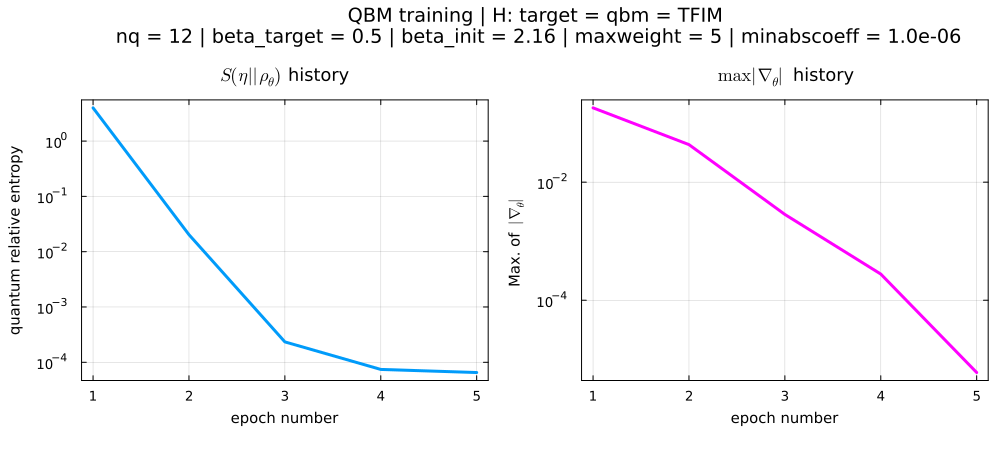

In [57]:
# gr()

# # ---- First plot ----
# p1 = plot(Optim.f_trace(result),
#     # xaxis = :log10,
#     yaxis = :log10,
#     xlabel = "epoch number",
#     ylabel = "quantum relative entropy",
#     title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
#     legend = false,
#     lw = 3,
#     titlefont = font(12),
#     guidefont = font(10),
#     tickfont = font(9),
#     margin = 5mm)

# # ---- Second plot ----
# p2 = plot(Optim.g_norm_trace(result),
#     # xaxis = :log10,
#     yaxis = :log10,
#     xlabel = "epoch number",
#     ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
#     title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
#     legend = false,
#     color = :fuchsia,
#     lw = 3,
#     titlefont = font(12),
#     guidefont = font(10),
#     tickfont = font(9),
#     margin = 5mm)

# # ---- Combine side by side ----
# combined = plot(
#     p1, p2,
#     layout = (1, 2),
#     size = (1000, 450),
#     plot_title = "QBM training | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=1)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff_qbm))",
#     plot_titlefont = font(13),
#     bottom_margin = 9mm,  
#     left_margin = 5mm,    
#     right_margin = 1mm,
#     top_margin = 10mm,
#     framestyle = :box,
#     titleloc = :center,
#     spacing = 10mm       
# )

# display(combined)

In [39]:
# --- Initialization ---
beta = rand(rng, Uniform(0, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 1000
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-6
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

num_layers = 1
max_weight = nq
min_abs_coeff = 1e-10

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_H_matrix = paulistringtomatrix(qbm_H_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_H_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_H_paulis)
    rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_H_paulis, target_eta_matrix, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_H_paulis, grads, gamma)

    # --- Diagnostics ---
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end

MethodError: MethodError: no method matching makehamiltonian(::HamiltonianParameters; connectivity::Symbol, periodic::Bool)
The function `makehamiltonian` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  makehamiltonian(::HamiltonianParameters, !Matched::Lattice; connectivity, periodic, model)
   @ PauliSampling ~/Desktop/PauliSampling.jl/src/QuantumBoltzmannMachine/hamiltonians.jl:176


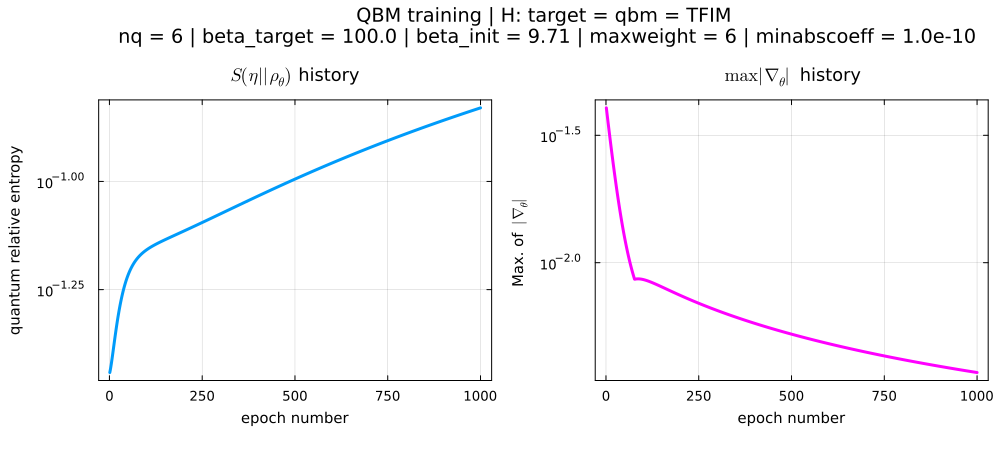

In [68]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    # xaxis = :log10,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=1)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight) | minabscoeff = $(@sprintf("%.1e", min_abs_coeff))",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

In [18]:
opt_coeffs = Optim.minimizer(result)
update_paulistring_coeffs!(qbm_H_paulis, opt_coeffs)

println("Optimization finished")
println("Final loss: ", Optim.minimum(result))

Optimization finished
Final loss: 0.10701072995620109


In [117]:
target_H_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta
target_H_paulis

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -14.841 * XIIIII)
 PauliString(nqubits: 6, -14.841 * IXIIII)
 PauliString(nqubits: 6, -14.841 * IIXIII)
 PauliString(nqubits: 6, -14.841 * IIIXII)
 PauliString(nqubits: 6, -14.841 * IIIIXI)
 PauliString(nqubits: 6, -14.841 * IIIIIX)
 PauliString(nqubits: 6, -5.5253 * ZZIIII)
 PauliString(nqubits: 6, -5.5253 * IZZIII)
 PauliString(nqubits: 6, -5.5253 * IIZZII)
 PauliString(nqubits: 6, -5.5253 * IIIZZI)
 PauliString(nqubits: 6, -5.5253 * IIIIZZ)

In [118]:
optimized_coeffs = Optim.minimizer(result)

11-element Vector{Float64}:
 -5.927653912359094
 -6.711199533563689
 -6.7315669265950415
 -6.731566925965977
 -6.711199532255159
 -5.927653911599575
 -2.3638652827480082
 -2.54805993675337
 -2.517892273225408
 -2.548059940387171
 -2.363865287382756

In [85]:
beta

2.6565486164222145

In [78]:
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -8.6448 * XIIIII)
 PauliString(nqubits: 6, -8.6448 * IXIIII)
 PauliString(nqubits: 6, -8.6448 * IIXIII)
 PauliString(nqubits: 6, -8.6448 * IIIXII)
 PauliString(nqubits: 6, -8.6448 * IIIIXI)
 PauliString(nqubits: 6, -8.6448 * IIIIIX)
 PauliString(nqubits: 6, -3.2184 * ZZIIII)
 PauliString(nqubits: 6, -3.2184 * IZZIII)
 PauliString(nqubits: 6, -3.2184 * IIZZII)
 PauliString(nqubits: 6, -3.2184 * IIIZZI)
 PauliString(nqubits: 6, -3.2184 * IIIIZZ)

In [22]:
final_loss = Optim.minimum(result)

0.10701072995620109

In [17]:
update_paulistring_coeffs!(qbm_H_paulis, optimized_coeffs)

In [21]:
qbm_H_paulis

19-element Vector{PauliString{PauliPropagation.UInt24, Float64}}:
 PauliString(nqubits: 10, -3.4448 * XIIIIIIIII)
 PauliString(nqubits: 10, -3.2527 * IXIIIIIIII)
 PauliString(nqubits: 10, -3.2449 * IIXIIIIIII)
 PauliString(nqubits: 10, -3.2443 * IIIXIIIIII)
 PauliString(nqubits: 10, -3.2442 * IIIIXIIIII)
 PauliString(nqubits: 10, -3.2442 * IIIIIXIIII)
 PauliString(nqubits: 10, -3.2443 * IIIIIIXIII)
 PauliString(nqubits: 10, -3.2449 * IIIIIIIXII)
 PauliString(nqubits: 10, -3.2527 * IIIIIIIIXI)
 PauliString(nqubits: 10, -3.4448 * IIIIIIIIIX)
 PauliString(nqubits: 10, -1.4796 * ZZIIIIIIII)
 PauliString(nqubits: 10, -1.4999 * IZZIIIIIII)
 PauliString(nqubits: 10, -1.5011 * IIZZIIIIII)
 PauliString(nqubits: 10, -1.5012 * IIIZZIIIII)
 PauliString(nqubits: 10, -1.5012 * IIIIZZIIII)
 PauliString(nqubits: 10, -1.5012 * IIIIIZZIII)
 PauliString(nqubits: 10, -1.5011 * IIIIIIZZII)
 PauliString(nqubits: 10, -1.4999 * IIIIIIIZZI)
 PauliString(nqubits: 10, -1.4796 * IIIIIIIIZZ)

# Coefficient truncation high $\beta$


Starting optimization for min_abs_coeff = 1.0e-03
Iter     Function value   Gradient norm 
     0     1.325931e+00     9.741804e-01
 * Current step size: 1.0
 * time: 9.202957153320312e-5
 * g(x): [0.9741803984127735, 0.954134043069513, 0.953045172124074, 0.953045172124074, 0.9541340430695133, 0.9741803984127737, 0.19218155432128303, 0.196442095078894, 0.19671845008091693, 0.1964420950788937, 0.19218155432128278]
 * x: [-0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406]
     1     2.620493e-01     8.817215e-02
 * Current step size: 4.902763696938428
 * time: 0.1710519790649414
 * g(x): [-0.019868726177095786, -0.03378204103202431, -0.034505782584449474, -0.03450625144168884, -0.033783707724056034, -0.01987534769258681, 0.08678684828313538, 0.08806784587840101, 0.08817214598076412, 0.08809161907035981, 0.0868443140748199

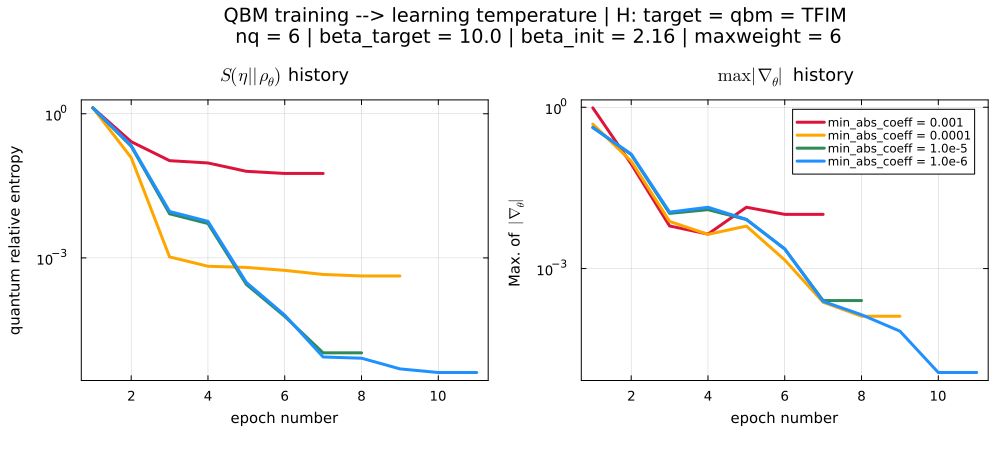

In [154]:
# target

nq = 6
target_beta = 10

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_matrix = makehamiltonian_matrix(params_target; connectivity=:nearest, periodic=false)

target_eta_matrix = makethermalstate_matrix(target_H_matrix, target_beta)
target_probs = computesymmetriceigenvalues(target_eta_matrix);

# QBM

beta = rand(rng, Uniform(1, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = 1000
max_weight_qbm = nq
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5, 1e-6]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    xticks = (x -> Int.(x)),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    xticks = (x -> Int.(x)),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = true,
        allow_f_increases = false,
        store_trace = true,
        extended_trace = true,
        g_tol = 1e-6,       # Stop if gradient is smaller than 0.0001
        f_tol = 1e-7,       # Stop if loss improves by less than 1e-9
    )

    result = optimize(
        coeffs -> loss_fun_logged(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),

        (g, coeffs) -> grad_fun_logged!(
            g, coeffs,
            qbm_H_paulis, target_eta_matrix,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
        ),

        initial_coeffs,     # x0
        LBFGS(),            # method
        opt;                
    )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # --- ADD TO PLOTS ---
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)

end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

In [ ]:
# target

nq = 10
target_beta = 50

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_matrix = makehamiltonian_matrix(params_target; connectivity=:nearest, periodic=false)

target_eta_matrix = makethermalstate_matrix(target_H_matrix, target_beta)
target_probs = computesymmetriceigenvalues(target_eta_matrix)

# QBM

beta = rand(rng, Uniform(1, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = 1000
max_weight_qbm = nq
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5, 1e-6]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    xticks = (x -> Int.(x)),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    xticks = (x -> Int.(x)),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = true,
        allow_f_increases = false,
        store_trace = true,
        extended_trace = true,
        g_tol = 1e-6,       # Stop if gradient is smaller than 0.0001
        f_tol = 1e-7,       # Stop if loss improves by less than 1e-9
    )

    result = optimize(
        coeffs -> loss_fun_logged(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),

        (g, coeffs) -> grad_fun_logged!(
            g, coeffs,
            qbm_H_paulis, target_eta_matrix,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
        ),

        initial_coeffs,     # x0
        LBFGS(),            # method
        opt;                
    )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # --- ADD TO PLOTS ---
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)

end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for min_abs_coeff = 1.0e-03
Iter     Function value   Gradient norm 
     0     2.451803e+00     9.823606e-01
 * Current step size: 1.0
 * time: 8.106231689453125e-5
 * g(x): [0.9823606305599708, 0.965182416853698, 0.9644503268394535, 0.9643976130620394, 0.9643930277281361, 0.9643930277281361, 0.9643976130620392, 0.9644503268394533, 0.9651824168536982, 0.9823606305599705, 0.18617701535500225, 0.1893462587709968, 0.18953594370104895, 0.18955129105275928, 0.1895525792698647, 0.1895512910527594, 0.18953594370104923, 0.189346258770997, 0.18617701535500222]
 * x: [-0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406]
     1     1.680731e+00     9.64

In [167]:
# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

In [158]:
# target

nq = 12
target_beta = 0.1

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))

params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_matrix = makehamiltonian_matrix(params_target; connectivity=:nearest, periodic=false)

target_eta_matrix = makethermalstate_matrix(target_H_matrix, target_beta)
target_probs = computesymmetriceigenvalues(target_eta_matrix);

# QBM

beta = rand(rng, Uniform(1, 10))    
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = 10
max_weight_qbm = nq
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5, 1e-6]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = true,
        allow_f_increases = false,
        store_trace = true,
        extended_trace = true,
        g_tol = 1e-6,       # Stop if gradient is smaller than 0.0001
        f_tol = 1e-7,       # Stop if loss improves by less than 1e-9
    )

    result = optimize(
        coeffs -> loss_fun_logged(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),

        (g, coeffs) -> grad_fun_logged!(
            g, coeffs,
            qbm_H_paulis, target_eta_matrix,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
        ),

        initial_coeffs,     # x0
        LBFGS(),            # method
        opt;                
    )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # --- ADD TO PLOTS ---
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)

end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)


Starting optimization for min_abs_coeff = 1.0e-03
Iter     Function value   Gradient norm 
     0     2.297023e+00     4.994045e-01
 * Current step size: 1.0
 * time: 9.989738464355469e-5
 * g(x): [-0.4994044984034186, -0.4946215524313608, -0.49440820036322314, -0.49417905243985477, -0.4939338257690537, -0.4936778662859006, -0.4934071719344045, -0.4931201991682634, -0.49303868056054645, -0.49284413089926693, -0.49255300839820654, -0.4967368220686824, -0.14905055521548127, -0.149051073069781, -0.1489881286304515, -0.14892541719789232, -0.14886291743253333, -0.14870097315528757, -0.14863902134285936, -0.14851998419704418, -0.14831528509008027, -0.14814582780198501, -0.14800496939645313]
 * x: [-0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.63982513302673, -0.2382030338081406, -0.2382030338081406, -0.2382030338081406, -0.2382

InterruptException: InterruptException:

# Different $\beta$


Starting optimization for min_abs_coeff = 1.0e-03

Starting optimization for min_abs_coeff = 1.0e-04

Starting optimization for min_abs_coeff = 1.0e-05

Starting optimization for min_abs_coeff = 1.0e-06
✅ Optimization data saved to: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N4_B1_20251204_163346.json


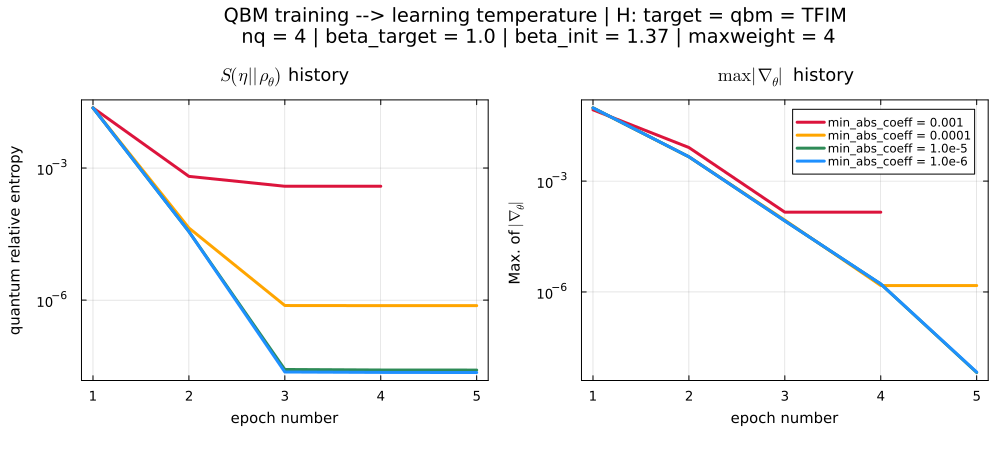

In [ ]:
# target

nq = 12
target_beta = 0.5

rng = MersenneTwister(3)

lat_2d = SquareLattice(4, 3)
params_target = parameters(:heisenberg, lat_2d.n; 
                     init=:zeros, 
                     coupling_vals=Dict(:XX => 1.0, :YY => 1.0, :ZZ => 1.0))
target_H_matrix = makehamiltonian_matrix(params_target, lat_2d; connectivity=:nearest, periodic=false)
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta)

# QBM
beta = rand(rng, Uniform(0.1, 10))
params = params_target
qbm_H_paulis = makehamiltonian(params, lat_2d; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = nq * 10
max_weight_qbm = 6
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5, 1e-6]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# --------------------------------------------- #
# --- Data Logging Setup --- #
# --------------------------------------------- #

# 1. Define the TARGET DIRECTORY
target_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# 2. Ensure the directory exists (create it if it doesn't)
# This prevents errors if the path is valid but the folder hasn't been created yet.
mkpath(target_dir)

# Initialize a structure to hold ALL results
all_results = Dict(
    "metadata" => Dict(
        "nq" => nq,
        "target_model" => "heisenberg",
        "dimension" => "2d",
        "topology" => "square lattice"
        "target_beta" => target_beta,
        "target_parameters" => params_target,
        "qbm_hamiltonian_model" => "heisenberg",
        "qbm_beta_init" => beta,
        "max_weight_qbm" => max_weight_qbm,
        "min_abs_coeff_qbm_list" => min_abs_coeff_qbm_list
    ),
    "runs" => [] # Array to hold results for each min_abs_coeff
)

# --- Define the output file name based on parameters ---
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
file_basename = "qbm_optimization_N$(nq)_B$(target_beta)_$(timestamp).json"

# 3. Combine the path and filename
filename = joinpath(target_dir, file_basename)

# ----------------------------- #
# --- INITIALIZE PLOTS --- #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
# --- MAIN OPTIMIZATION --- #
# ----------------------------- #
for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = false, # Set to false for faster runs, as data is saved
        allow_f_increases = false,
        store_trace = true,
        extended_trace = false, # False to save memory
        g_tol = 1e-6,
        f_tol = 1e-7,
        )

    result = optimize(
        coeffs -> loss_fun(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),
        (g, coeffs) -> grad_fun!(
            g, coeffs,
            qbm_H_paulis, target_eta_matrix,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
            ),
        initial_coeffs, # x0
        LBFGS(), # method
        opt;
        )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # 💡 DATA LOGGING: Save the results for the current run
    push!(all_results["runs"], Dict(
        "min_abs_coeff" => min_abs_coeff_qbm,
        "final_loss" => Optim.minimum(result),
        "final_g_norm" => Optim.g_residual(result), # Use g_residual for final norm
        "iterations_total" => Optim.iterations(result),
        "f_trace" => f_data,
        "g_norm_trace" => g_data
        ))

    # --- ADD TO PLOTS ---
    # Ensure x-axis is correct for plotting later (1:length(f_data))
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)
end

# ----------------------------- #
# --- FINAL SAVE TO FILE --- #
# ----------------------------- #

open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("="^60)
println("✅ Optimization data saved to: $filename")
println("="^60)

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,
    left_margin = 5mm,
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

In [ ]:
# target

nq = 4
target_beta = 1

rng = MersenneTwister(3)
target_interaction = rand(rng, Uniform(-1, 1))
target_field = rand(rng, Uniform(-1, 1))
params_target = parameters(:tfim, nq; field_vals=Dict(:X => target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_H_matrix = jordan_wigner_tfim(nq, J=target_interaction, h=target_field)
Gamma = get_covariance_matrix(target_H_matrix, target_beta)
target_probs = 
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta)

# QBM
beta = rand(rng, Uniform(0.1, 10))
params = params_target
qbm_H_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta;

num_layers_qbm = nq * 10
max_weight_qbm = nq
min_abs_coeff_qbm_list = [1e-3, 1e-4, 1e-5, 1e-6]
colors = [:crimson, :orange, :seagreen, :dodgerblue]

initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis)
qbm_H_paulis_template = deepcopy(qbm_H_paulis)

# --------------------------------------------- #
# --- Data Logging Setup --- #
# --------------------------------------------- #

# 1. Define the TARGET DIRECTORY
target_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# 2. Ensure the directory exists (create it if it doesn't)
# This prevents errors if the path is valid but the folder hasn't been created yet.
mkpath(target_dir)

# Initialize a structure to hold ALL results
all_results = Dict(
    "metadata" => Dict(
        "nq" => nq,
        "target_model" => "tfim",
        "target_beta" => target_beta,
        "target_parameters" => params_target,
        "qbm_hamiltonian_model" => "tfim",
        "qbm_beta_init" => beta,
        "max_weight_qbm" => max_weight_qbm,
        "min_abs_coeff_qbm_list" => min_abs_coeff_qbm_list
    ),
    "runs" => [] # Array to hold results for each min_abs_coeff
)

# --- Define the output file name based on parameters ---
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
file_basename = "qbm_optimization_N$(nq)_B$(target_beta)_$(timestamp).json"

# 3. Combine the path and filename
filename = joinpath(target_dir, file_basename)

# ----------------------------- #
# --- INITIALIZE PLOTS --- #
# ----------------------------- #

p1 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legend = false
)

p2 = plot(
    yaxis = :log10,
    # xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm,
    legendfontsize = 8,
)

# ----------------------------- #
# --- MAIN OPTIMIZATION --- #
# ----------------------------- #
for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)

    println("\n" * "="^60)
    @printf("Starting optimization for min_abs_coeff = %.1e\n", min_abs_coeff_qbm)
    println("="^60)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(
        iterations = 30000,
        show_trace = false, # Set to false for faster runs, as data is saved
        allow_f_increases = false,
        store_trace = true,
        extended_trace = false, # False to save memory
        g_tol = 1e-6,
        f_tol = 1e-7,
        )

    result = optimize(
        coeffs -> loss_fun(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),
        (g, coeffs) -> grad_fun!(
            g, coeffs,
            qbm_H_paulis, target_eta_matrix,
            nq, num_layers_qbm,
            max_weight_qbm, min_abs_coeff_qbm
            ),
        initial_coeffs, # x0
        LBFGS(), # method
        opt;
        )

    f_data = Optim.f_trace(result)
    g_data = Optim.g_norm_trace(result)

    # 💡 DATA LOGGING: Save the results for the current run
    push!(all_results["runs"], Dict(
        "min_abs_coeff" => min_abs_coeff_qbm,
        "final_loss" => Optim.minimum(result),
        "final_g_norm" => Optim.g_residual(result), # Use g_residual for final norm
        "iterations_total" => Optim.iterations(result),
        "f_trace" => f_data,
        "g_norm_trace" => g_data
        ))

    # --- ADD TO PLOTS ---
    # Ensure x-axis is correct for plotting later (1:length(f_data))
    plot!(p1, f_data; color = colors[i], lw = 3)
    plot!(p2, g_data; label = "min_abs_coeff = $(min_abs_coeff_qbm)", color = colors[i], lw = 3)
end

# ----------------------------- #
# --- FINAL SAVE TO FILE --- #
# ----------------------------- #

open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("="^60)
println("✅ Optimization data saved to: $filename")
println("="^60)

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training --> learning temperature | H: target = qbm = TFIM\n nq = $(nq) | beta_target = $(round(target_beta, digits=2)) | beta_init = $(round(beta, digits=2)) | maxweight = $(max_weight_qbm)",
    plot_titlefont = font(13),
    bottom_margin = 9mm,
    left_margin = 5mm,
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)

# -----------

Imports and Environment Setup

In [11]:
using PauliSampling
using Random, Distributions, Optim, JSON3, Dates, Printf
using Plots, LaTeXStrings, Measures

# ------------------------------------------------------------------ #
# --- Directory Setup --- #
# ------------------------------------------------------------------ #
# Define the TARGET DIRECTORY for saving results
target_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"
mkpath(target_dir) # Ensure the directory exists

println("Environment initialized. Data will be saved to: ", target_dir)

Environment initialized. Data will be saved to: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature


Optimization Loop

In [ ]:
# 1. Target System Configuration
nq = 12
target_beta = 0.5
rng = MersenneTwister(3)

# Define the 2D Geometry (4x3 = 12 spins)
lat_2d = SquareLattice(4, 3)

# Initialize Antiferromagnetic Heisenberg parameters (J=1.0)
params_target = parameters(:heisenberg, lat_2d.n; 
                     init=:zeros, 
                     coupling_vals=Dict(:XX => 1.0, :YY => 1.0, :ZZ => 1.0))

# Build target matrices
target_H_matrix = makehamiltonian_matrix(params_target, lat_2d; connectivity=:nearest, periodic=false)
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta)

# 2. QBM Initialization
beta_init = rand(rng, Uniform(0.1, 10))
qbm_H_paulis_template = makehamiltonian(params_target, lat_2d; connectivity=:nearest, periodic=false) * beta_init

num_layers_qbm = 10
max_weight_qbm = 5
min_abs_coeff_qbm_list = [2.0^-12, 2.0^-14, 2.0^-16, 2.0^-18]

# 3. Optimization Data Logging Structure
all_results = Dict(
    "metadata" => Dict(
        "nq" => nq,
        "target_beta" => target_beta,
        "qbm_beta_init" => beta_init,
        "max_weight_qbm" => max_weight_qbm,
        "min_abs_coeff_qbm_list" => min_abs_coeff_qbm_list
    ),
    "runs" => [] 
)

# 4. Main Optimization Loop
initial_coeffs_template = coeffs_from_paulistrings(qbm_H_paulis_template)

for (i, min_abs_coeff_qbm) in enumerate(min_abs_coeff_qbm_list)
    @printf("\nOptimizing for min_abs_coeff = %.1e...\n", min_abs_coeff_qbm)

    initial_coeffs = deepcopy(initial_coeffs_template)
    qbm_H_paulis = deepcopy(qbm_H_paulis_template)

    opt = Optim.Options(iterations = 30000, g_tol = 1e-4, f_tol = 1e-4, store_trace = true)

    result = optimize(
        coeffs -> loss_fun(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),
        (g, coeffs) -> grad_fun!(g, coeffs, qbm_H_paulis, target_eta_matrix, nq, num_layers_qbm, max_weight_qbm, min_abs_coeff_qbm),
        initial_coeffs, 
        LBFGS(), 
        opt
    )

    push!(all_results["runs"], Dict(
        "min_abs_coeff" => min_abs_coeff_qbm,
        "f_trace" => Optim.f_trace(result),
        "g_norm_trace" => Optim.g_norm_trace(result)
    ))
end

# 5. Save results to File
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
filename = joinpath(target_dir, "qbm_optimization_N$(nq)_$(timestamp).json")

open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("✅ Optimization complete. Data saved to: ", filename)


Optimizing for min_abs_coeff = 2.4e-04...

Optimizing for min_abs_coeff = 6.1e-05...

Optimizing for min_abs_coeff = 1.5e-05...

Optimizing for min_abs_coeff = 3.8e-06...
✅ Optimization complete. Data saved to: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json


Plotting and Visualization

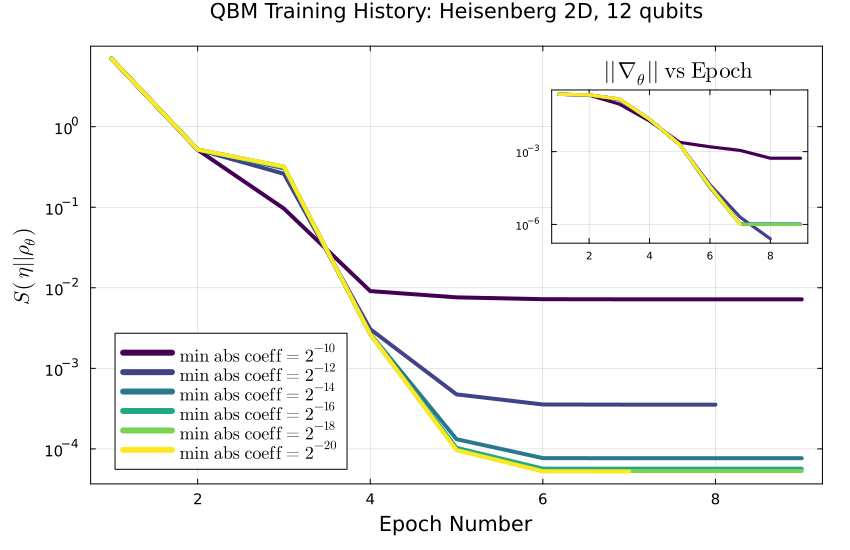

In [104]:
# 1. Load Data
filename = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json"
all_results = JSON3.read(open(filename, "r"))

runs = all_results["runs"]
meta = all_results["metadata"]

# 2. Define a Dynamic Gradient
num_runs = length(runs)
line_colors = palette(:viridis, num_runs) # This is your list of colors

# 3. Main Plot (Cost Function History)
p_main = plot(
    yaxis = :log10,
    xlabel = "Epoch Number",
    ylabel = L"S\,\left(\eta || \rho\!_\theta\right)",
    title = "QBM Training History: Heisenberg 2D, 12 qubits",
    lw = 2.5,
    size = (850, 550),
    legend = :bottomleft,
    legendfontsize = 12,
    guidefont = font(14),  # Sets size for both xlabel and ylabel
    tickfont = font(10),
    framestyle = :box,
    margin = 5mm,
)

# 3. Create Inset for Gradient Norm
plot!(p_main, 
    inset = (1, bbox(0.63, 0.55, 0.35, 0.35, :bottom, :left)),
    subplot = 2,
    yaxis = :log10,
    # xlabel = "Epoch",
    # ylabel = L"||\nabla_\theta||",
    title = L"||\!\nabla_\theta\,|| \mathrm{vs \ Epoch}",
    titlefont = font(15),
    guidefont = font(8),
    tickfont = font(7),
    legend = false,
    framestyle = :box,
    grid = true
)

# 4. Populate Plot with Saved Traces
for (i, run) in enumerate(runs)

    exponent = Int(round(log2(run["min_abs_coeff"])))
    lbl = L"\mathrm{min \ abs \ coeff =} 2^{%$(exponent)}"
        
    # Subplot 1: Loss function
    plot!(p_main, run["f_trace"], 
          subplot = 1, 
          color = line_colors[i], # Matches the dynamic palette variable
          label = lbl, 
          lw = 4)
    
    # Subplot 2: Gradient norm
    plot!(p_main, run["g_norm_trace"], 
          subplot = 2, 
          color = line_colors[i], # Matches the dynamic palette variable
          lw = 3.2)
end

display(p_main)

In [64]:
# 1. Specify the EXISTING file path
filename = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json"

# 2. Load the existing data
all_results = JSON3.read(open(filename, "r"), Dict)

# 3. Setup the NEW simulation parameters (min_abs_coeff = 2^-20)
new_coeff = 2.0^-20
println("\nStarting separate optimization for min_abs_coeff = 2^-20...")

# Use the metadata already stored in the file to ensure consistency
nq = all_results["metadata"]["nq"]
target_beta = all_results["metadata"]["target_beta"]
max_weight_qbm = all_results["metadata"]["max_weight_qbm"]
num_layers_qbm = 10 # Matches your previous run

# Re-build templates (ensure these match your previous environment setup)
lat_2d = SquareLattice(4, 3)
params_target = parameters(:heisenberg, lat_2d.n; 
                     init=:zeros, 
                     coupling_vals=Dict(:XX => 1.0, :YY => 1.0, :ZZ => 1.0))

target_H_matrix = makehamiltonian_matrix(params_target, lat_2d; connectivity=:nearest, periodic=false)
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta)

# Use the same initialization logic
beta_init = all_results["metadata"]["qbm_beta_init"]
qbm_H_paulis = makehamiltonian(params_target, lat_2d; connectivity=:nearest, periodic=false) * beta_init
initial_coeffs = coeffs_from_paulistrings(qbm_H_paulis)

# 4. Run the optimization
opt = Optim.Options(iterations = 30000, g_tol = 1e-6, f_tol = 1e-7, store_trace = true)

result = optimize(
    coeffs -> loss_fun(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),
    (g, coeffs) -> grad_fun!(g, coeffs, qbm_H_paulis, target_eta_matrix, nq, num_layers_qbm, max_weight_qbm, new_coeff),
    initial_coeffs, 
    LBFGS(), 
    opt
)

# 5. MERGE: Push the new run into the existing "runs" list
push!(all_results["runs"], Dict(
    "min_abs_coeff" => new_coeff,
    "f_trace" => Optim.f_trace(result),
    "g_norm_trace" => Optim.g_norm_trace(result)
))

# Update metadata list to include the new coefficient for record-keeping
push!(all_results["metadata"]["min_abs_coeff_qbm_list"], new_coeff)

# 6. SAVE: Overwrite the file with the updated dictionary
open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("✅ New simulation merged. Updated file: ", filename)


Starting separate optimization for min_abs_coeff = 2^-20...
✅ New simulation merged. Updated file: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json


In [71]:
# 1. Specify the EXISTING file path
filename = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json"

# 2. Load the existing data
all_results = JSON3.read(open(filename, "r"), Dict)

# 3. Setup the NEW simulation parameters (min_abs_coeff = 2^-20)
new_coeff = 2.0^-10
println("\nStarting separate optimization for min_abs_coeff = 2^-10...")

# Use the metadata already stored in the file to ensure consistency
nq = all_results["metadata"]["nq"]
target_beta = all_results["metadata"]["target_beta"]
max_weight_qbm = all_results["metadata"]["max_weight_qbm"]
num_layers_qbm = 10 # Matches your previous run

# Re-build templates (ensure these match your previous environment setup)
lat_2d = SquareLattice(4, 3)
params_target = parameters(:heisenberg, lat_2d.n; 
                     init=:zeros, 
                     coupling_vals=Dict(:XX => 1.0, :YY => 1.0, :ZZ => 1.0))

target_H_matrix = makehamiltonian_matrix(params_target, lat_2d; connectivity=:nearest, periodic=false)
target_eta_matrix, target_probs = makethermalstate_matrix(target_H_matrix, target_beta)

# Use the same initialization logic
beta_init = all_results["metadata"]["qbm_beta_init"]
qbm_H_paulis = makehamiltonian(params_target, lat_2d; connectivity=:nearest, periodic=false) * beta_init
initial_coeffs = coeffs_from_paulistrings(qbm_H_paulis)

# 4. Run the optimization
opt = Optim.Options(iterations = 30000, g_tol = 1e-4, f_tol = 1e-4, store_trace = true)

result = optimize(
    coeffs -> loss_fun(coeffs, qbm_H_paulis, target_eta_matrix, target_probs),
    (g, coeffs) -> grad_fun!(g, coeffs, qbm_H_paulis, target_eta_matrix, nq, num_layers_qbm, max_weight_qbm, new_coeff),
    initial_coeffs, 
    LBFGS(), 
    opt
)

# 5. MERGE: Push the new run into the existing "runs" list
push!(all_results["runs"], Dict(
    "min_abs_coeff" => new_coeff,
    "f_trace" => Optim.f_trace(result),
    "g_norm_trace" => Optim.g_norm_trace(result)
))

# Update metadata list to include the new coefficient for record-keeping
push!(all_results["metadata"]["min_abs_coeff_qbm_list"], new_coeff)

# 6. SAVE: Overwrite the file with the updated dictionary
open(filename, "w") do f
    JSON3.pretty(f, all_results)
end

println("✅ New simulation merged. Updated file: ", filename)


Starting separate optimization for min_abs_coeff = 2^-10...
✅ New simulation merged. Updated file: /Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json


In [72]:
# macOS desktop notification (works in VS Code + Jupyter)
run(`osascript -e 'display notification "✅ Julia notebook finished" with title "VS Code"'`)


Process(`osascript -e 'display notification "✅ Julia notebook finished" with title "VS Code"'`, ProcessExited(0))